In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import os
from datetime import datetime
import seaborn.objects as so
sns.despine()

<Figure size 640x480 with 0 Axes>

In [ ]:
camera_offset = datetime.timedelta(seconds=1.76) #seconds
video_start = datetime.datetime(2025, 11, 3, 16, 36, 27)
def get_timestamp_from_frame(video_start, attack_stop,wrong_fr=True):
  if wrong_fr:
    attack_stop = attack_stop/3
  print(attack_stop)
  return (attack_stop+camera_offset)+video_start

NameError: name 'datetime' is not defined

In [ ]:
print(get_timestamp_from_frame(video_start,datetime.timedelta(minutes=11,seconds=45)))

NameError: name 'get_timestamp_from_frame' is not defined

In [ ]:
'/content/drive/MyDrive/Jocasta - Rotation 2025/video_data/aggression_data/20251104/logs/20251104_PJA121_intruder1_day9_withphotostim20251104_14_06_44_time_log.csv'[100:103]

'121'

In [3]:
sheet_name = '/content/drive/MyDrive/Jocasta - Rotation 2025/video_data/old_format/old_format_121.csv'
old_format_121 = pd.read_csv(sheet_name)
old_format_121 =old_format_121.drop(columns=['light'])
date_format = '%Y-%m-%d_%H:%M:%S'
list_starttimes = list(old_format_121['start_times'])
list_attackstoptimes = list(old_format_121['attack_stop_times'])
old_format_121['time_to_stop'] = [(datetime.strptime(a,date_format) - datetime.strptime(s,date_format)).total_seconds() for a,s in zip(list_attackstoptimes,list_starttimes)]
old_format_121['mouse_id'] = [str(id_) for id_ in list(old_format_121['mouse_id'])]
old_format_121.head()


,start_times,attack_stop_times,on_status,attack_number,mouse_id,end_times,time_to_stop
0,2025-10-31_15:32:34,2025-10-31_15:32:54,False,0,121,2025-10-31_15:32:44,20.0
1,2025-10-31_15:32:48,2025-10-31_15:33:07,False,1,121,2025-10-31_15:32:58,19.0
2,2025-10-31_15:33:05,2025-10-31_15:33:15,True,2,121,2025-10-31_15:33:15,10.0
3,2025-10-31_15:33:18,2025-10-31_15:33:26,True,3,121,2025-10-31_15:33:28,8.0
4,2025-10-31_15:33:34,2025-10-31_15:33:35,True,4,121,2025-10-31_15:33:44,1.0


In [4]:
# !pip install pandas numpy matplotlib seaborn scipy
###########DATA PROCESSING AND ANALYSIS#################

############REFORMAT DATA########################

data_directory = '/content/drive/MyDrive/Jocasta - Rotation 2025/video_data/aggression_data'
data_dates = os.listdir(data_directory)
log_folders = [os.path.join(data_directory, date,'logs') for date in data_dates]
log_files = []

for folder in log_folders:
    files = os.listdir(folder)
    log_files += [os.path.join(folder, file) for file in files if file.endswith('.csv')]

df_list = []
mouse_ids = [log_files[0][100:103] for file in log_files]

for file_ in log_files:
    df = pd.read_csv(file_)
    df['mouse_id'] = [str(file_[100:103]) for i in range(len(df))]
    df_list.append(df)
data = pd.concat(df_list, ignore_index=True)
data.rename(columns={"Unnamed: 0": "attack_number"},inplace=True)
date_format = '%Y-%m-%d_%H:%M:%S.%f'
list_starttimes = list(data['start_times'])
list_attackstoptimes = list(data['attack_stop_times'])
data['time_to_stop'] = [(datetime.strptime(a,date_format) - datetime.strptime(s,date_format)).total_seconds() for a,s in zip(list_attackstoptimes,list_starttimes)]


data= pd.concat((data,old_format_121))
data['light_on_status'] = ['ON' if status else 'OFF' for status in data['on_status']]
data.tail()


,attack_number,start_times,attack_stop_times,end_times,on_status,mouse_id,time_to_stop,light_on_status
10,4,2025-10-31_16:04:50,2025-10-31_16:04:59,2025-10-31_16:05:00,False,121,9.0,OFF
11,0,2025-10-31_16:20:51,2025-10-31_16:21:10,2025-10-31_16:21:01,False,121,19.0,OFF
12,1,2025-10-31_16:31:57,2025-10-31_16:32:20,2025-10-31_16:32:07,False,121,23.0,OFF
13,0,2025-11-03_14:13:25,2025-11-03_14:13:32,2025-11-03_14:13:35,True,121,7.0,ON
14,0,2025-11-03_14:34:51,2025-11-03_14:35:00,2025-11-03_14:35:01,False,121,9.0,OFF


In [6]:
first_attack = data[data['attack_number'] == 0]
ids=list(first_attack['mouse_id'])
ids.count('121')

8

In [11]:
data[data['mouse_id'] == '121']

,attack_number,start_times,attack_stop_times,end_times,on_status,mouse_id,time_to_stop,light_on_status
68,0,2025-11-07_13:43:50.854019,2025-11-07_13:43:52.308149,2025-11-07_13:44:00.876895,True,121,1.454130,ON
69,0,2025-11-07_13:13:26.362448,2025-11-07_13:13:28.265003,2025-11-07_13:13:36.375816,False,121,1.902555,OFF
96,0,2025-11-06_14:28:44.041737,2025-11-06_14:28:53.288428,2025-11-06_14:28:54.057328,False,121,9.246691,OFF
97,1,2025-11-06_14:29:37.757957,2025-11-06_14:29:39.132377,2025-11-06_14:29:47.773301,False,121,1.374420,OFF
0,0,2025-10-31_15:32:34,2025-10-31_15:32:54,2025-10-31_15:32:44,False,121,20.000000,OFF
1,1,2025-10-31_15:32:48,2025-10-31_15:33:07,2025-10-31_15:32:58,False,121,19.000000,OFF
2,2,2025-10-31_15:33:05,2025-10-31_15:33:15,2025-10-31_15:33:15,True,121,10.000000,ON
3,3,2025-10-31_15:33:18,2025-10-31_15:33:26,2025-10-31_15:33:28,True,121,8.000000,ON
4,4,2025-10-31_15:33:34,2025-10-31_15:33:35,2025-10-31_15:33:44,True,121,1.000000,ON
5,5,2025-10-31_15:33:52,2025-10-31_15:33:55,2025-10-31_15:34:02,True,121,3.000000,ON


In [8]:
#filter data frames into CTRL and light on
light_on = data[data['on_status'] == True]
light_off = data[data['on_status'] == False]

In [ ]:
sp.stats.ranksums(light_on[light_on['mouse_id'] == '122']['time_to_stop'], light_off[light_off['mouse_id'] == '122']['time_to_stop'])

RanksumsResult(statistic=np.float64(1.1477609080469748), pvalue=np.float64(0.25106727934470663))

In [ ]:
light_on[light_on['mouse_id'] == '123'].describe()

,time_to_stop
count,3.000000
mean,1.806610
std,1.216846
min,1.082786
25%,1.104173
50%,1.125559
75%,2.168522
max,3.211486


In [ ]:
light_off[light_off['mouse_id'] == '123'].describe()

,time_to_stop
count,4.000000
mean,2.443861
std,2.692266
min,0.668013
25%,0.814145
50%,1.349252
75%,2.978968
max,6.408927


In [ ]:
light_off.describe()

,time_to_stop
count,64.000000
mean,4.188484
std,5.663639
min,0.445582
25%,1.242800
50%,1.869101
75%,3.279858
max,24.000000


In [ ]:
light_on.describe()

,time_to_stop
count,61.000000
mean,3.217577
std,2.943279
min,0.658198
25%,1.234698
50%,2.173811
75%,3.645652
max,14.350840


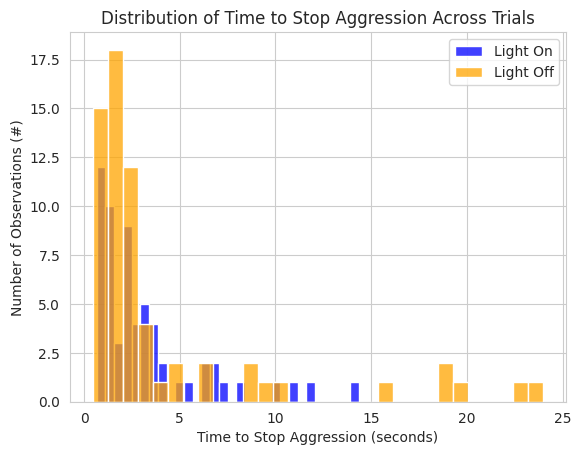

In [ ]:
#Plotting
sns.set_style("whitegrid")
sns.histplot(light_on['time_to_stop'], color='blue', label='Light On', stat='count', bins=30)
sns.histplot(light_off['time_to_stop'], color='orange', label='Light Off', stat='count', bins=30)
plt.xlabel('Time to Stop Aggression (seconds)')
plt.ylabel('Number of Observations (#)')
plt.title('Distribution of Time to Stop Aggression Across Trials')
plt.legend()
plt.show()


Text(0, 0.5, 'Time to Stop Aggression (seconds)')

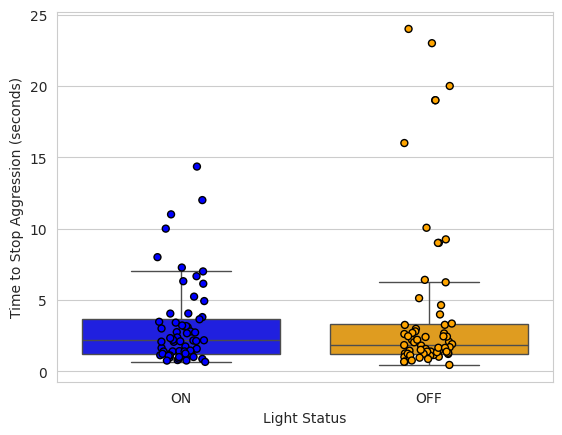

In [ ]:
light_palette = {'ON':'blue', 'OFF':'orange'}
sns.boxplot(x='light_on_status', y = 'time_to_stop',data=data,hue='light_on_status',palette=light_palette,showfliers=False)
sns.stripplot(x='light_on_status', y = 'time_to_stop',data=data,hue='light_on_status',palette=light_palette,edgecolor='black',linewidth=1,legend=False)
plt.xlabel('Light Status')
plt.ylabel('Time to Stop Aggression (seconds)')

In [ ]:
#report summary statistics for each group (# attacks per mouse, #trials, median IQR and range, mean and stdev)

In [ ]:
sp.stats.ranksums(light_on['time_to_stop'], light_off['time_to_stop'])

RanksumsResult(statistic=np.float64(0.27659127289275987), pvalue=np.float64(0.78209396658972))

Text(392.83986928104576, 0.5, '')

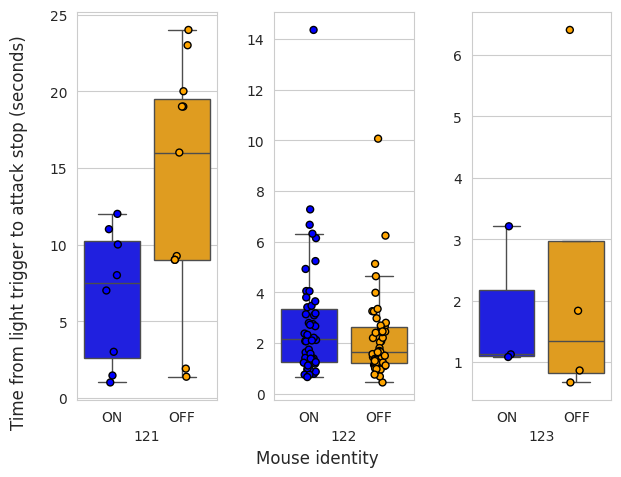

In [ ]:
###per mouse analysis### --doesn't loook right, are the mice swapped?
fig, axs = plt.subplots(ncols=3)
fig.supylabel("Time from light trigger to attack stop (seconds)")
fig.supxlabel("Mouse identity")
fig.tight_layout()
sns.boxplot(x='light_on_status', y = 'time_to_stop',palette=light_palette,data=data[data['mouse_id'] == '121'],hue='light_on_status', ax=axs[0],showfliers=False)
sns.stripplot(x='light_on_status', y = 'time_to_stop',data=data[data['mouse_id'] == '121'],hue='light_on_status',palette=light_palette,edgecolor='black',linewidth=1,legend=False, ax=axs[0])
axs[0].set_xlabel('121')
axs[0].set_ylabel('')
sns.boxplot(x='light_on_status', y = 'time_to_stop',palette=light_palette,data=data[data['mouse_id'] == '122'],hue='light_on_status', ax=axs[1],showfliers=False)
sns.stripplot(x='light_on_status', y = 'time_to_stop',data=data[data['mouse_id'] == '122'],hue='light_on_status',palette=light_palette,edgecolor='black',linewidth=1,legend=False, ax=axs[1])
axs[1].set_xlabel('122')
axs[1].set_ylabel('')
sns.boxplot(x='light_on_status', y = 'time_to_stop',palette=light_palette,data=data[data['mouse_id'] == '123'],hue='light_on_status', ax=axs[2],showfliers=False)
sns.stripplot(x='light_on_status', y = 'time_to_stop',data=data[data['mouse_id'] == '123'],hue='light_on_status',palette=light_palette,edgecolor='black',linewidth=1,legend=False, ax=axs[2])
axs[2].set_xlabel('123')
axs[2].set_ylabel('')

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


AttributeError: 'FacetGrid' object has no attribute 'supylabel'

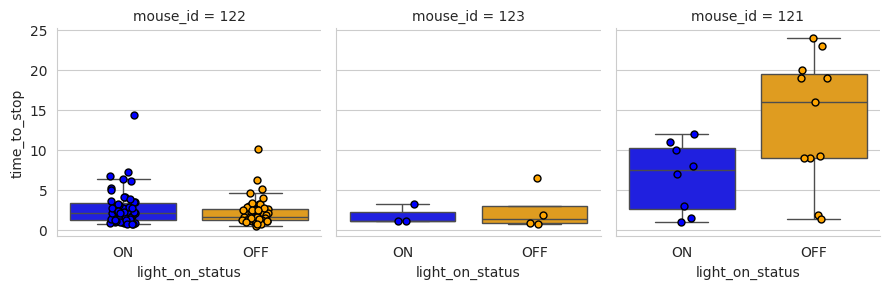

In [ ]:
g = sns.FacetGrid(data, col="mouse_id", hue='light_on_status',palette=light_palette)
g.map(sns.boxplot, "light_on_status", "time_to_stop",showfliers=False)
g.map(sns.stripplot, "light_on_status", "time_to_stop",edgecolor='black',linewidth=1)
g.supylabel("Time to attack stop (seconds)")
g.add_legend()

/usr/local/lib/python3.12/dist-packages/seaborn/_core/plot.py:1406: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0 0 1 0 1 0 1 2 3 0 1 0 1 2 3 0 1 2 3 4 5 6 7 8 9 10 0 1 2 0 0 0 1 2 0 0
 0 0 1 2 0 1 2 3 4 5 6 7 8 9 10 11 0 1 2 3 4 5 6 7 8 9 10 11 0 1 2 3 0 0 0
 0 1 2 0 1 2 3 4 5 6 7 8 9 10 11 0 1 2 3 4 0 0 1 2 3 0 1 0 0 0 1 0 1 0 1 0
 1 2 3 0 1 2 3 4 5 0 1 2 3 4 0 1 0 0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  new_series.loc[idx] = view_scale(layer_df.loc[idx, var])


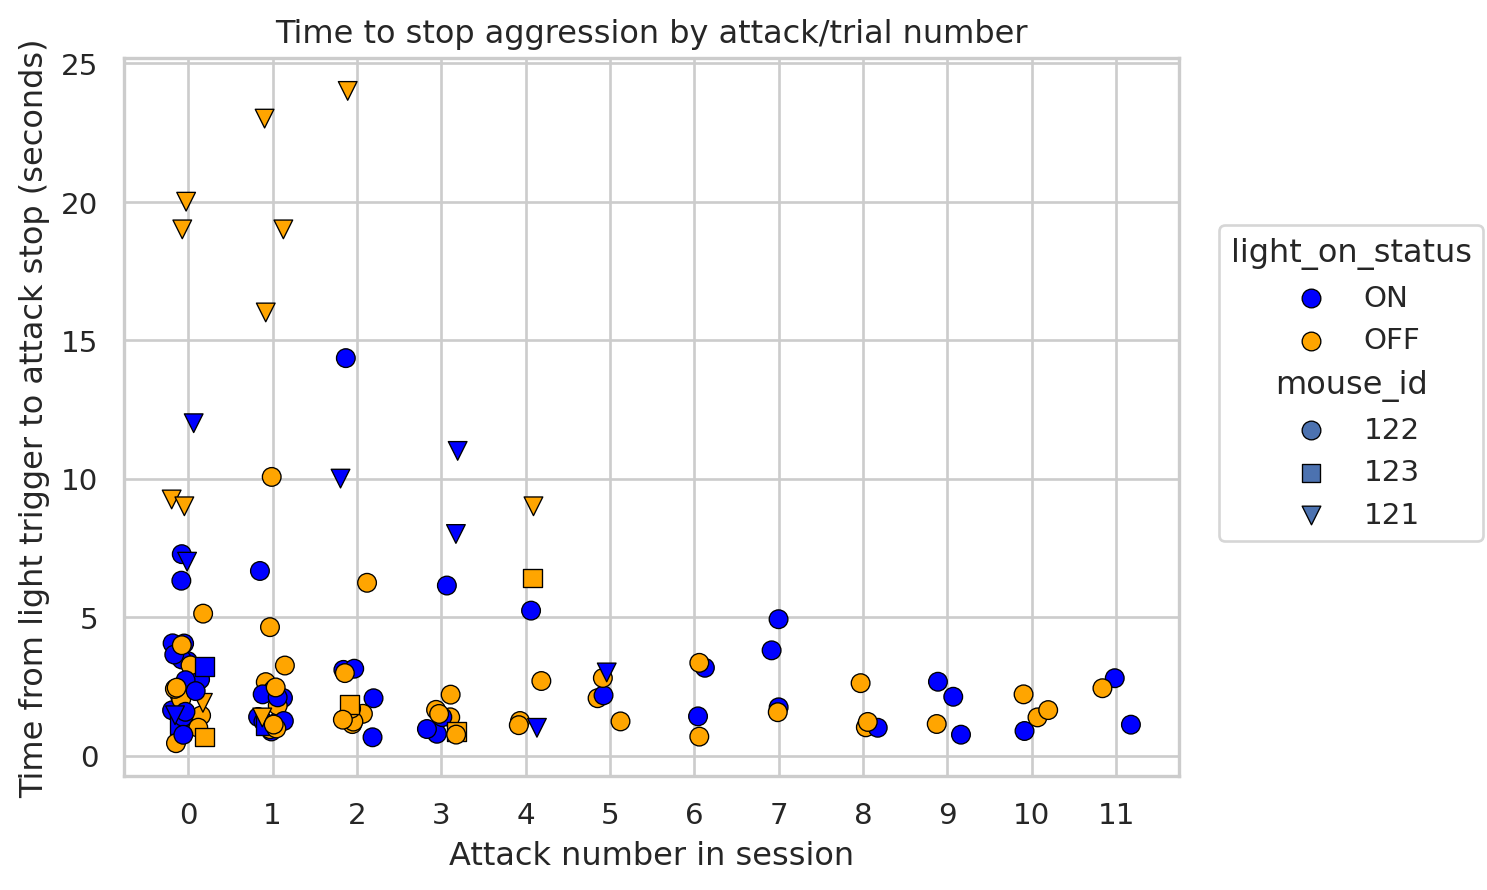

In [ ]:
from seaborn import axes_style
theme_dict = {**axes_style("whitegrid")}
so.Plot.config.theme.update(theme_dict)
coldict={'ON':'blue','OFF':'orange'}
markdict={'121':'v','122':'o','123':'s'}

(
    so.Plot(data, x="attack_number", y="time_to_stop", color="light_on_status", marker="mouse_id")
    .add(
        so.Dot(pointsize=7, edgecolor="black"),
        # so.Dodge(), # use this if you want to separate the markers with different colors
        so.Jitter(0.5)
    )
    .label(
        y="Time from light trigger to attack stop (seconds)", x="Attack number in session",
        title="Time to stop aggression by attack/trial number"
    )
    .scale(

        x=so.Continuous().tick(every=1),
        color=so.Nominal(coldict),
        marker=so.Nominal(markdict)
    ))

In [ ]:
data.head()

,attack_number,start_times,attack_stop_times,end_times,on_status,mouse_id,time_to_stop,color_code,on_status_words
0,0,2025-11-18_15:38:54.493889,2025-11-18_15:38:56.126468,2025-11-18_15:39:04.496160,True,122,1.632579,122 - True,ON
1,0,2025-11-18_15:15:47.304482,2025-11-18_15:15:48.247670,2025-11-18_15:15:57.328099,True,122,0.943188,122 - True,ON
2,1,2025-11-18_15:21:50.927144,2025-11-18_15:21:52.161842,2025-11-18_15:22:00.945643,True,122,1.234698,122 - True,ON
3,0,2025-11-18_14:55:58.042822,2025-11-18_14:56:05.314557,2025-11-18_14:56:08.055044,True,122,7.271735,122 - True,ON
4,1,2025-11-18_15:03:23.128497,2025-11-18_15:03:29.793256,2025-11-18_15:03:33.135949,True,122,6.664759,122 - True,ON


In [ ]:
#latency (time to NEXT attack after stim on/off)
#clear variable
data_iti = None
df_list = []
for file in log_files:
    df = pd.read_csv(file)
    iti = []
    list_starts = df['start_times']
    for i in range(len(df)-1):
        # print((datetime.strptime(list_starts[i+1],date_format) - datetime.strptime(list_starts[i],date_format)).total_seconds())
        iti.append((datetime.strptime(list_starts[i+1],date_format) - datetime.strptime(list_starts[i],date_format)).total_seconds())
    print(iti)
    df['iti'] = iti + [np.nan]
    df_list.append(df)
data_iti = pd.concat(df_list, ignore_index=True).dropna()
data_iti.tail()

[]
[]
[]
[363.622662]
[]
[445.085675]
[]
[510.509791, 125.418832, 23.323291]
[]
[948.377031]
[]
[60.61538, 417.474267, 118.682173]
[]
[27.837572, 22.124358, 30.856134, 96.954919, 18.852693, 128.368484, 23.225429, 93.96249, 129.797787, 286.17653]
[171.977281, 654.551145]
[]
[]
[]
[]
[486.950229, 62.082681]
[]
[]
[]
[]
[]
[]
[]
[140.261034, 109.673302]
[44.529393, 59.387747, 20.579678, 61.907505, 150.13425, 64.682109, 14.593901, 49.864525, 114.642068, 208.452111, 87.648613]
[]
[14.615479, 16.695553, 135.949878, 94.099511, 50.52106, 52.033199, 36.503777, 223.977597, 14.249905, 76.031521, 191.931782]
[12.245011, 136.309558, 69.838294]
[]
[]
[]
[]
[]
[]
[]
[19.986247, 170.202336]
[19.199056, 37.507887, 42.510281, 70.415949, 204.729159, 42.337905, 67.693271, 248.807618, 30.928829, 40.029575, 219.94154]
[338.133613, 16.478918, 27.644321, 138.642089]
[]
[]
[]
[]
[]
[51.511946, 128.55095, 100.699631]
[53.71622]
[]
[]
[79.714904]
[]
[]
[]
[31.890956]
[59.324603]
[]
[]
[]
[288.869748, 313.76787, 

,Unnamed: 0,start_times,attack_stop_times,end_times,on_status,iti
127,0,2025-11-14_14:57:04.370036,2025-11-14_14:57:10.683587,2025-11-14_14:57:14.387087,True,31.890956
129,0,2025-11-14_15:13:20.605089,2025-11-14_15:13:21.354011,2025-11-14_15:13:30.620847,True,59.324603
134,0,2025-11-14_14:24:03.752837,2025-11-14_14:24:07.737169,2025-11-14_14:24:13.771182,False,288.869748
135,1,2025-11-14_14:28:52.622585,2025-11-14_14:28:53.740652,2025-11-14_14:29:02.647632,False,313.767870
136,2,2025-11-14_14:34:06.390455,2025-11-14_14:34:07.048653,2025-11-14_14:34:16.394953,True,20.184258


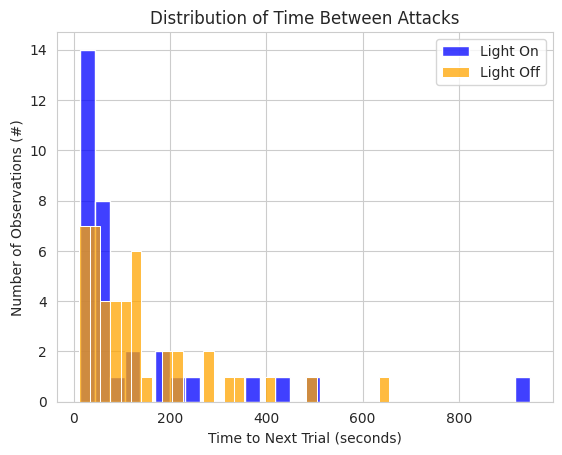

In [ ]:
#Plotting
light_on_iti = data_iti[data_iti['on_status'] == True]
light_off_iti = data_iti[data_iti['on_status'] == False]
sns.set_style("whitegrid")
sns.histplot(light_on_iti['iti'], color='blue', label='Light On', stat='count', bins=30)
sns.histplot(light_off_iti['iti'], color='orange', label='Light Off', stat='count', bins=30)
plt.xlabel('Time to Next Trial (seconds)')
plt.ylabel('Number of Observations (#)')
plt.title('Distribution of Time Between Attacks')
plt.legend()
plt.show()

Text(0.5, 0, 'Light On?')

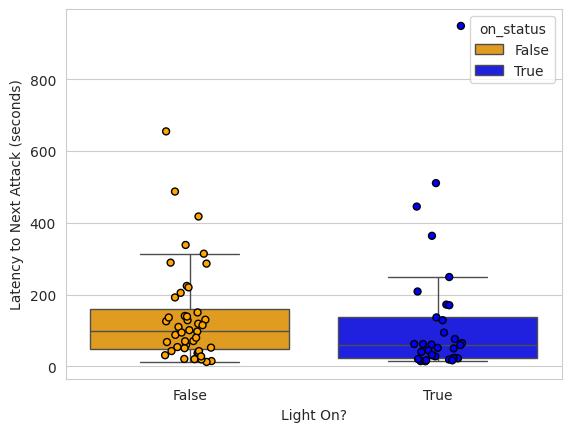

In [ ]:
sns.boxplot(x='on_status', y = 'iti',data=data_iti,hue='on_status',palette=light_palette,showfliers=False)
sns.stripplot(x='on_status', y = 'iti',data=data_iti,hue='on_status',palette=light_palette,edgecolor='black',linewidth=1,legend=False)
plt.ylabel('Latency to Next Attack (seconds)')
plt.xlabel('Light On?')

In [ ]:
sp.stats.ranksums(light_on_iti['iti'], light_off_iti['iti'])

RanksumsResult(statistic=np.float64(-1.6366549857180974), pvalue=np.float64(0.10170257953884745))

In [ ]:
#total number of attacks per session